# Lesson 5 — State Estimation & Robust Control

*ESP2110 Inverted Pendulum Lab*

**Run in Google Colab:** open the notebook, run the **Setup** cell once, then run
cells top-to-bottom. No local files are required.

## Learning objectives
By the end of this notebook you can:
1. Check **observability** — decide whether the full state can be reconstructed from the sensors you actually have.
2. Build a **Luenberger observer** to estimate the unmeasured velocities, and drive the controller from the *estimate*.
3. State and **verify the separation principle** — controller and observer poles can be chosen independently.
4. Replace naive numerical differentiation with a **Kalman filter** and see why it matters under measurement noise.
5. Stress-test the design against **parameter drift** (wrong pole length / cart mass).

### The setup that makes this lesson necessary
In Lessons 4A–4C the controller used the **full state** `x = [p, p_dot, theta, theta_dot]`.
On real hardware you do **not** measure velocities directly — you have a cart-position
encoder and a pole-angle sensor. So you measure only

$$y = \begin{bmatrix} p \\ \theta \end{bmatrix},\qquad C = \begin{bmatrix} 1&0&0&0 \\ 0&0&1&0 \end{bmatrix}.$$

The velocities must be **estimated**. That is what this lesson is about.

### Parameters (same plant as Lessons 4A/4B/4C)
| Symbol | Meaning | Value |
| --- | --- | --- |
| `m_c` | Cart mass | 0.5 kg |
| `m_p` | Pole mass | 0.2 kg |
| `L` | Pole length | 0.3 m |
| `g` | Gravity | 9.81 m/s^2 |
| `dt` | Sample time | 0.01 s |

In [1]:
# --- Setup (safe to re-run) ---
try:
    import numpy, scipy, matplotlib  # noqa: F401
except ImportError:
    import sys, subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                    'numpy', 'scipy', 'matplotlib'], check=True)
print('Environment ready.')

Environment ready.


---
## Recap: the plant and the full-state controller

We reuse the exact plant and the full-state feedback gain `K` from Lesson 4B
(closed-loop poles placed at -2, -3, -4, -5). The only thing that changes is that
the controller can no longer see the whole state — it sees `y = [p, theta]`.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

m_c, m_p, L, g, dt = 0.5, 0.2, 0.3, 9.81, 0.01

def f_nonlin(s, f, Lt=L, mc=m_c, mp=m_p):
    """Full nonlinear cart-pole. Lt/mc/mp overridable for the drift study."""
    p, v, th, om = s
    sin, cos = np.sin(th), np.cos(th)
    den = mc + mp * sin**2
    vdot  = (f + mp * sin * (Lt * om**2 - g * cos)) / den
    omdot = (-f * cos - mp * Lt * om**2 * sin * cos + (mc + mp) * g * sin) / (Lt * den)
    return np.array([v, vdot, om, omdot])

A = np.array([
    [0, 1, 0,                       0],
    [0, 0, -m_p * g / m_c,          0],
    [0, 0, 0,                       1],
    [0, 0, (m_c + m_p) * g / (L * m_c), 0],
])
B = np.array([0, 1 / m_c, 0, -1 / (L * m_c)]).reshape(4, 1)

# Full-state feedback gain from Lesson 4B
K = signal.place_poles(A, B, [-2, -3, -4, -5]).gain_matrix.ravel()

# We measure ONLY cart position p and pole angle theta
C = np.array([[1, 0, 0, 0],
              [0, 0, 1, 0]])

print('K =', np.round(K, 3))
print('We measure y = C x =', ['p', 'theta'])

K = [ -1.835  -2.355 -18.067  -2.806]
We measure y = C x = ['p', 'theta']


## Part 1 - Can you even reconstruct the state? (observability)

Before building an estimator, ask whether the measurements *contain enough information*
to reconstruct the full state. The test is the **observability matrix**

$$\mathcal{O} = \begin{bmatrix} C \\ CA \\ CA^2 \\ CA^3 \end{bmatrix}.$$

The system is observable **iff** `rank(O) = 4` (one row-block per state dimension).

In [3]:
O = np.vstack([C @ np.linalg.matrix_power(A, i) for i in range(4)])
print('O shape', O.shape, ' rank', np.linalg.matrix_rank(O))
print('Observable!' if np.linalg.matrix_rank(O) == 4 else 'NOT observable')


O shape (8, 4)  rank 4
Observable!


**Expected output.** `O` is an 8x4 matrix with **rank 4** -> the system is **observable**.
Measuring position and angle is enough to reconstruct the (unmeasured) velocities.
If you tried to measure *only* `p` or *only* `theta`, recompute the rank and see what happens.

## Part 2 - A Luenberger observer

The observer is a copy of the model that is continuously corrected by the measurement error:

$$\dot{\hat{x}} = A\hat{x} + Bf + L\,(y - C\hat{x}).$$

The estimation error `e = x - x_hat` obeys `e_dot = (A - LC) e`, so we choose `L` to place
the eigenvalues of `A - LC` in the left-half plane. **Rule of thumb:** make the observer
2-4x faster than the controller so the estimate converges before the controller leans on it.
We place observer poles at **-8, -10, -12, -14** (controller poles were -2,-3,-4,-5).

We compute `L` by pole placement on the *dual* system `(A^T, C^T)`: `L = place(A^T, C^T).T`.

eig(A - L_obs C) = [ -8. -14. -10. -12.]


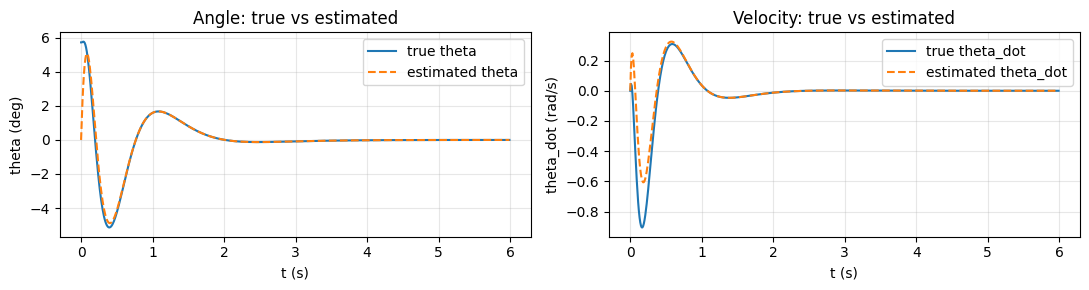

max |theta| = 5.77 deg; final cart = -0.0 m


In [4]:
# Observer gain via the dual system
L_obs = signal.place_poles(A.T, C.T, [-8, -10, -12, -14]).gain_matrix.T
print('eig(A - L_obs C) =', np.round(np.linalg.eigvals(A - L_obs @ C), 2))

def sim_output_feedback(T=6.0, x0=None, plant='nonlinear'):
    """Controller uses the OBSERVER estimate: f = -K x_hat."""
    n = int(T / dt)
    x  = np.array([0, 0, 0.1, 0.0]) if x0 is None else x0.copy()
    xh = np.zeros(4)                      # observer starts ignorant
    X = np.zeros((n, 4)); XH = np.zeros((n, 4))
    for k in range(n):
        f = float(-K @ xh)                # control from the ESTIMATE
        y = C @ x                         # only p and theta are measured
        X[k] = x; XH[k] = xh
        xh = xh + dt * (A @ xh + B.ravel() * f + L_obs @ (y - C @ xh))
        x  = x + dt * (A @ x + B.ravel() * f if plant == 'linear' else f_nonlin(x, f))
    return np.arange(n) * dt, X, XH

t, X, XH = sim_output_feedback()
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].plot(t, np.degrees(X[:, 2]), label='true theta')
ax[0].plot(t, np.degrees(XH[:, 2]), '--', label='estimated theta')
ax[0].set(title='Angle: true vs estimated', xlabel='t (s)', ylabel='theta (deg)'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(t, X[:, 3], label='true theta_dot')
ax[1].plot(t, XH[:, 3], '--', label='estimated theta_dot')
ax[1].set(title='Velocity: true vs estimated', xlabel='t (s)', ylabel='theta_dot (rad/s)'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()
print('max |theta| =', round(np.degrees(np.abs(X[:, 2]).max()), 2), 'deg; final cart =', round(X[-1, 0], 3), 'm')


**Expected output.** The estimated velocity starts at zero (the observer is ignorant) but
**locks onto the true velocity within a few tenths of a second**, after which the dashed and
solid curves overlap. The pole is stabilized using *only* `p` and `theta` measurements
(initial swing ~5.8 deg because the controller acts on a wrong estimate during the first instants).

### The separation principle (eigenvalue verification)

Stack the true state and the estimation error. The closed loop becomes

$$\begin{bmatrix}\dot{x}\\\dot{e}\end{bmatrix}=\begin{bmatrix}A-BK & BK\\ 0 & A-LC\end{bmatrix}\begin{bmatrix}x\\e\end{bmatrix}.$$

Because the matrix is block-triangular, its eigenvalues are exactly the **union** of the
controller poles `eig(A-BK)` and the observer poles `eig(A-LC)`. So you can design them
independently. Let's confirm it numerically.

In [5]:
Acl = np.block([[A - B @ K.reshape(1, 4), B @ K.reshape(1, 4)],
                [np.zeros((4, 4)),         A - L_obs @ C    ]])
print('controller eig(A-BK) =', np.round(np.sort(np.linalg.eigvals(A - B @ K.reshape(1, 4)).real), 2))
print('observer   eig(A-LC) =', np.round(np.sort(np.linalg.eigvals(A - L_obs @ C).real), 2))
print('augmented  eig       =', np.round(np.sort(np.linalg.eigvals(Acl).real), 2))


controller eig(A-BK) = [-5. -4. -3. -2.]
observer   eig(A-LC) = [-14. -12. -10.  -8.]
augmented  eig       = [-14. -12. -10.  -8.  -5.  -4.  -3.  -2.]


## Part 3 - Measurement noise: naive differentiation vs the Kalman filter

Real sensors are noisy. A tempting shortcut is to get velocities by **finite-differencing**
the measured position and angle: `v ~= (y[k] - y[k-1]) / dt`. Differentiation **amplifies
noise** — dividing small random jitter by `dt = 0.01` blows it up 100x, and that noise goes
straight into the control force.

The **Kalman filter** is the optimal observer for known noise statistics: it is the
Luenberger observer with a gain that is continuously rebalanced between trusting the model
(`Q`) and trusting the measurement (`R`). Compare the two on the **control effort**.

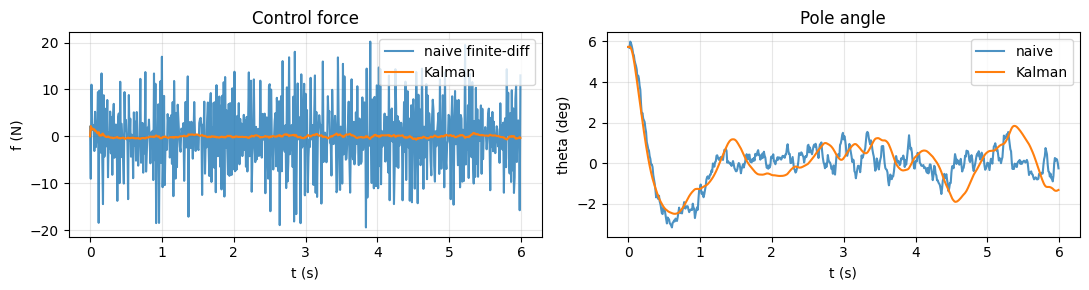

naive : force std  = 7.4 N, peak |f| = 20.2 N
kalman: force std  = 0.24 N, peak |f| = 2.2 N


In [6]:
meas_std = np.array([0.005, np.radians(1.0)])   # 5 mm position, 1 deg angle
R = np.diag(meas_std**2)
Q = np.diag([1e-6, 1e-4, 1e-6, 1e-4])
A_d = np.eye(4) + A * dt                        # discrete model for the KF

def run_noisy(method, seed=1, T=6.0):
    rng = np.random.default_rng(seed); n = int(T / dt)
    x = np.array([0, 0, 0.1, 0.0]); F = np.zeros(n); TH = np.zeros(n)
    xh = np.zeros(4); P = np.eye(4) * 0.1; y_prev = C @ x
    for k in range(n):
        ns = meas_std * rng.standard_normal(2)
        y = C @ x + ns
        if method == 'naive':
            vel = (y - y_prev) / dt if k > 0 else np.zeros(2); y_prev = y
            xh = np.array([y[0], vel[0], y[1], vel[1]])
            f = float(-K @ xh)
        else:  # kalman
            f = float(-K @ xh)
            xp = xh + dt * (A @ xh + B.ravel() * f)         # predict
            Pp = A_d @ P @ A_d.T + Q
            S = C @ Pp @ C.T + R                            # update
            Kf = Pp @ C.T @ np.linalg.inv(S)
            xh = xp + Kf @ (y - C @ xp); P = (np.eye(4) - Kf @ C) @ Pp
        F[k] = f; TH[k] = x[2]
        x = x + dt * f_nonlin(x, f)
    return np.arange(n) * dt, F, TH

t, Fn, THn = run_noisy('naive')
t, Fk, THk = run_noisy('kalman')
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].plot(t, Fn, alpha=.8, label='naive finite-diff'); ax[0].plot(t, Fk, label='Kalman')
ax[0].set(title='Control force', xlabel='t (s)', ylabel='f (N)'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(t, np.degrees(THn), alpha=.8, label='naive'); ax[1].plot(t, np.degrees(THk), label='Kalman')
ax[1].set(title='Pole angle', xlabel='t (s)', ylabel='theta (deg)'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()
print('naive : force std  =', round(np.std(Fn[100:]), 2), 'N, peak |f| =', round(np.abs(Fn).max(), 1), 'N')
print('kalman: force std  =', round(np.std(Fk[100:]), 2), 'N, peak |f| =', round(np.abs(Fk).max(), 1), 'N')


**Expected output.** Both keep the pole near upright, but the **control force tells the real
story**: naive differentiation produces a force that **chatters with std ~7 N and peaks ~20 N**,
while the Kalman filter is **~30x smoother (std ~0.2 N, peak ~2 N)**. On hardware the chattering
naive controller would scream, overheat the motor, and wear the gears — even though the angle
plot looks "fine." *Smooth state estimates -> smooth control.*

## Part 4 - Robustness: what if your model is wrong?

We designed `K` and `L` for `L = 0.3 m`, `m_c = 0.5 kg`. Real parameters are never exact.
Sweep the *true* plant parameter while keeping the controller/observer fixed, and find where
the design stops working.

In [7]:
def survives(Lt=L, mc=m_c, T=6.0):
    n = int(T / dt); x = np.array([0, 0, 0.1, 0.0]); xh = np.zeros(4); mx = 0.0
    for k in range(n):
        f = float(-K @ xh); y = C @ x
        xh = xh + dt * (A @ xh + B.ravel() * f + L_obs @ (y - C @ xh))
        x = x + dt * f_nonlin(x, f, Lt=Lt, mc=mc)
        if not np.all(np.isfinite(x)) or abs(x[2]) > np.pi / 2:
            return None
        mx = max(mx, abs(x[2]))
    return np.degrees(mx)

print('Pole-length drift (design L = 0.3 m):')
for frac in [0.7, 1.0, 1.5, 1.9, 2.1, 2.3]:
    mx = survives(Lt=0.3 * frac)
    print(f'  L = {0.3*frac:.2f} m ({int(frac*100):3d}%): ' + (f'max|theta| = {mx:5.1f} deg' if mx else 'FELL OVER'))

print('Cart-mass drift (design m_c = 0.5 kg):')
for frac in [0.5, 1.0, 1.8, 2.0, 3.0]:
    mx = survives(mc=0.5 * frac)
    print(f'  m_c = {0.5*frac:.2f} kg ({int(frac*100):3d}%): ' + (f'max|theta| = {mx:5.1f} deg' if mx else 'FELL OVER'))


Pole-length drift (design L = 0.3 m):
  L = 0.21 m ( 70%): max|theta| =   5.8 deg
  L = 0.30 m (100%): max|theta| =   5.8 deg
  L = 0.45 m (150%): max|theta| =   5.8 deg
  L = 0.57 m (190%): max|theta| =   9.6 deg
  L = 0.63 m (210%): max|theta| =  40.0 deg
  L = 0.69 m (229%): FELL OVER
Cart-mass drift (design m_c = 0.5 kg):
  m_c = 0.25 kg ( 50%): max|theta| =   9.0 deg
  m_c = 0.50 kg (100%): max|theta| =   5.8 deg
  m_c = 0.90 kg (180%): FELL OVER
  m_c = 1.00 kg (200%): FELL OVER
  m_c = 1.50 kg (300%): FELL OVER


**Expected output.** The design is **very robust to pole length** — it tolerates roughly
0.7x to ~1.9x the design length, degrades badly by ~2.1x, and falls over past ~2.3x. It is
**much more sensitive to cart mass**: a cart only ~1.8x heavier than assumed already topples the pole. The lesson: robustness is
**parameter-specific**. Identify your most uncertain *and* most sensitive parameter and either
measure it carefully or design for the worst case.

## Part 5 - Watch it balance from estimates (animation)

The cart-pole below is stabilized using **only** position and angle measurements — the
controller never sees the true velocities. The faint pole is the observer's estimate; watch it
snap onto the true (solid) pole within the first moments.

In [8]:
from matplotlib import animation
from IPython.display import HTML

t, X, XH = sim_output_feedback(T=6.0)
frames = np.arange(0, len(X), 12)
fig, ax = plt.subplots(figsize=(6, 3))
ax.set_ylim(-0.15, 0.45); ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.set_title('Observer-based balancing (measures p, theta only)'); ax.set_xlabel('x (m)')
cart = plt.Rectangle((-0.12, 0.0), 0.24, 0.12, fc='steelblue', ec='k'); ax.add_patch(cart)
pole, = ax.plot([], [], lw=3, color='crimson')
bob,  = ax.plot([], [], 'o', color='crimson', ms=9)
est,  = ax.plot([], [], lw=3, color='gray', alpha=0.45)      # observer estimate

def _update(j):
    i = frames[j]
    p, th = X[i, 0], X[i, 2]
    ph, thh = p, XH[i, 2]                                     # show estimated angle at true cart
    cart.set_xy((p - 0.12, 0.0))
    tx, ty = p + L * np.sin(th), 0.12 + L * np.cos(th)
    pole.set_data([p, tx], [0.12, ty]); bob.set_data([tx], [ty])
    ex, ey = ph + L * np.sin(thh), 0.12 + L * np.cos(thh)
    est.set_data([ph, ex], [0.12, ey])
    ax.set_xlim(p - 0.7, p + 0.7)
    return cart, pole, bob, est

anim = animation.FuncAnimation(fig, _update, frames=len(frames), interval=60, blit=False)
plt.close(fig)
HTML(anim.to_jshtml())


---
## Checkpoints
- Observability matrix is 8x4 with **rank 4** -> the state is reconstructable from `p` and `theta`.
- The observer's estimated velocity converges to the true velocity within a few tenths of a second.
- Augmented closed-loop eigenvalues equal the **union** of controller poles {-2,-3,-4,-5} and observer poles {-8,-10,-12,-14} (separation principle).
- Under noise, the Kalman filter gives **dramatically smoother control force** than naive differentiation (~0.2 N vs ~7 N std).
- The design tolerates large pole-length error (to ~1.9x) but topples under a ~1.8x cart-mass error.

## Common pitfalls
- **Controlling on raw noisy measurements.** Finite-differencing position/angle for velocity
  injects huge noise into the force. Estimate, don't differentiate.
- **Observer too slow.** If observer poles are not faster than controller poles, the controller
  acts on a stale estimate and performance (or stability) degrades.
- **Wrong `L` construction.** `place_poles(A.T, C.T)` returns a gain whose **transpose** is `L`.
  Forgetting the `.T` gives wrong shapes/results.
- **Trusting the angle plot alone.** A controller can keep `theta` near zero while the *force*
  chatters destructively. Always inspect the control effort.
- **Assuming "robust to one parameter" means "robust."** Sensitivity is parameter-specific;
  check each uncertain parameter separately.